In [1]:
# --- Cell 1 — Set up directories (for Kaggle) ---

import os

# Base directory for QuickDraw .npy files
# If you're using a Kaggle Dataset (attached via "Add Data"), 
# replace this with the mounted path (e.g., '/kaggle/input/quickdraw-npy')
base_dir = '/kaggle/working/quickdraw_npy'
os.makedirs(base_dir, exist_ok=True)

# Directory to store trained models, checkpoints, and artifacts
model_dir = '/kaggle/working/model'
os.makedirs(model_dir, exist_ok=True)

# Directory for logs (TensorBoard)
logs_dir = '/kaggle/working/logs'
os.makedirs(logs_dir, exist_ok=True)

print("Base dir:", base_dir)
print("Model dir:", model_dir)
print("Logs dir:", logs_dir)


Base dir: /kaggle/working/quickdraw_npy
Model dir: /kaggle/working/model
Logs dir: /kaggle/working/logs


In [2]:
# --- Cell 2 — Environment Setup (Kaggle-Optimized) ---

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Check TensorFlow version and GPU status
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# OPTIONAL: clear session (helps avoid crashes when rerunning cells)
tf.keras.backend.clear_session()

# Kaggle already includes:
# tensorflow, numpy, pandas, matplotlib, scikit-learn, etc.
# So we don't need any pip installs.


2025-11-02 18:12:55.523395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762107175.782302      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762107175.848837      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
Num GPUs Available: 2


In [3]:
# --- Cell 3: Load or Download QuickDraw .npy Files (Selective Classes) ---

# Step 1: Import essentials
import os
import numpy as np
from pathlib import Path
import urllib.request

# Step 2: Define the base directory where .npy files will be stored
base_dir = '/content/quickdraw_npy'
os.makedirs(base_dir, exist_ok=True)  # create if missing

# Step 3: Define 20 simple and visually distinct QuickDraw classes
classes = [
    'apple', 'banana', 'butterfly', 'car', 'cat', 'cloud',
    'cup', 'dog', 'fish', 'flower', 'hand', 'house',
    'moon', 'sun', 'star', 'tree', 'umbrella', 'ice cream',
    'shoe', 'clock'
]

# Step 4: Define how many samples per class to load
SAMPLES_PER_CLASS = 50000

# Step 5: Helper function to download .npy file if it doesn't exist
def download_npy(cls, dest_dir=base_dir, max_attempts=5):
    """
    Downloads the .npy file for the given class name from Google's QuickDraw dataset
    if it isn't already present locally. Retries up to `max_attempts` times.
    """
    # Replace spaces in class names with URL-safe encoding
    safe_cls = cls.replace(" ", "%20")
    url = f'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{safe_cls}.npy'
    file_path = os.path.join(dest_dir, f'{cls}.npy')

    if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
        print(f"{cls}.npy already exists")
        return file_path

    for attempt in range(1, max_attempts + 1):
        try:
            print(f"Downloading {cls}.npy (Attempt {attempt}) ...")
            urllib.request.urlretrieve(url, file_path)
            print(f"Downloaded {cls}.npy successfully")
            return file_path
        except Exception as e:
            print(f"Attempt {attempt} failed: {e}")
    print(f"Failed to download {cls}.npy after {max_attempts} attempts")
    return None

# Step 6: Download all required classes
npy_files = {}
for cls in classes:
    path = download_npy(cls)
    if path:
        npy_files[cls] = path

# Step 7: Load data into memory (limit to SAMPLES_PER_CLASS per class)
X, y = [], []
for label, (cls, path) in enumerate(npy_files.items()):
    data = np.load(path)
    print(f"{cls}: loaded {len(data)} samples")

    # Take only the first SAMPLES_PER_CLASS (or fewer if not available)
    data = data[:SAMPLES_PER_CLASS]

    X.append(data)
    y.append(np.full(data.shape[0], label))

# Step 8: Combine all classes into a single dataset
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

print(f"\nFinal dataset shape: {X.shape}, labels: {y.shape}")
print(f"Total samples: {len(X):,} across {len(classes)} classes")

# Step 9: Create a label map for reference
label_map = {i: cls for i, cls in enumerate(classes)}
print("\nLabel map:")
print(label_map)


Downloaded apple.npy successfully
Downloaded banana.npy successfully
Downloaded butterfly.npy successfully
Downloaded car.npy successfully
Downloaded cat.npy successfully
Downloaded cloud.npy successfully
Downloaded cup.npy successfully
Downloaded dog.npy successfully
Downloaded fish.npy successfully
Downloaded flower.npy successfully
Downloaded hand.npy successfully
Downloaded house.npy successfully
Downloaded moon.npy successfully
Downloaded sun.npy successfully
Downloaded star.npy successfully
Downloaded tree.npy successfully
Downloaded umbrella.npy successfully
Downloaded ice cream.npy successfully
Downloaded shoe.npy successfully
Downloaded clock.npy successfully
apple: loaded 144722 samples
banana: loaded 307936 samples
butterfly: loaded 117999 samples
car: loaded 182764 samples
cat: loaded 123202 samples
cloud: loaded 120265 samples
cup: loaded 130721 samples
dog: loaded 152159 samples
fish: loaded 134150 samples
flower: loaded 144818 samples
hand: loaded 291773 samples
house: l

In [4]:
# --- Cell 4: Preprocessing, Normalization, and Train-Test Split ---

from sklearn.model_selection import train_test_split
import tensorflow as tf

# --- FIX: We must split the 1D y array BEFORE one-hot encoding ---
# Step 1: Reshape X
X_shaped = X.reshape(-1, 28, 28, 1).astype('float32')
# Step 2: Normalize X
X_normalized = X_shaped / 255.0
# y is still the 1D array (1000000,) from Cell 3

# Step 3: Split into train and test sets (80:20)
# This will now work because 'y' is 1D
X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)
# --- END FIX ---

# Step 4: Now we one-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train_labels, num_classes=len(label_map))
y_test = tf.keras.utils.to_categorical(y_test_labels, num_classes=len(label_map))

# **Crucial:** Save the 1D test labels for Cell 11 (metrics)
y_true = y_test_labels

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"y_train (one-hot) shape: {y_train.shape}")
print(f"y_test (one-hot) shape: {y_test.shape}")
print(f"Image shape: {X_train.shape[1:]}")

Training samples: 800000, Test samples: 200000
y_train (one-hot) shape: (800000, 20)
y_test (one-hot) shape: (200000, 20)
Image shape: (28, 28, 1)


In [5]:
# --- Cell 5: Define Model Constants & Callbacks ---

# --- FIX: Import specific callbacks ---
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
import os
import datetime
# --- END FIX ---

# Define constants
NUM_CLASSES = len(label_map)
INPUT_SHAPE = (28, 28, 1)
PRETRAINED_INPUT_SHAPE = (96, 96, 3) # MobileNetV2 works well with this size
BATCH_SIZE = 512 # Increase batch size to leverage GPU memory

# --- Define Callbacks (using Kaggle paths) ---
# 1. Model Checkpoint: Save the best model only
checkpoint_path = "/kaggle/working/model_checkpoint.weights.h5"
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 2. Early Stopping: Stop training if validation accuracy doesn't improve
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Stop after 5 epochs of no improvement
    restore_best_weights=True,
    verbose=1
)

# 3. TensorBoard: For visualizing training (optional but good practice)
logs_dir = '/kaggle/working/logs' # Use the directory from Cell 1
log_dir = os.path.join(logs_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Input shape: {INPUT_SHAPE}")
print(f"Target pre-trained shape: {PRETRAINED_INPUT_SHAPE}")

Number of classes: 20
Input shape: (28, 28, 1)
Target pre-trained shape: (96, 96, 3)


In [6]:
# --- Cell 6: Build the Transfer Learning Model (FINAL FIX) ---

import tensorflow as tf
from tensorflow.keras import layers, models

def build_transfer_model(input_shape, target_shape, num_classes):
    """
    Builds a Keras model using MobileNetV2 transfer learning.
    This version replaces the problematic Lambda layer with a
    standard Concatenate layer.
    """
    
    # --- 1. Pre-processing Layers ---
    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    
    # Resize to the target shape (e.g., 96x96)
    x = layers.Resizing(target_shape[0], target_shape[1], name="resize")(inputs)
    
    # --- THIS IS THE FIX ---
    # We replace the Lambda layer with a standard Concatenate layer.
    # We concatenate the 1-channel image with itself 3 times along
    # the channel axis (axis=-1) to create a 3-channel image.
    # This layer saves and loads perfectly without any errors.
    x = layers.Concatenate(axis=-1, name="to_rgb")([x, x, x])
    # --- END OF FIX ---

    # Rescale our [0, 1] input images to the [-1, 1] range
    x = layers.Rescaling(2.0, offset=-1.0, name="rescale_to_mobilenet_range")(x)
    
    # --- 2. Pre-trained Base Model ---
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=target_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    x = base_model(x, training=False)

    # --- 3. New Classification Head ---
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dense(128, activation='relu', name="dense_128")(x)
    x = layers.Dropout(0.5, name="dropout_0.5")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output_softmax")(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build and compile the model
model = build_transfer_model(INPUT_SHAPE, PRETRAINED_INPUT_SHAPE, NUM_CLASSES)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print the model structure
model.summary()

I0000 00:00:1762107206.030830      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762107206.031806      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize (Resizing)   │ (None, 96, 96, 1) │          0 │ input_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ to_rgb              │ (None, 96, 96, 3) │          0 │ resize[0][0],     │
│ (Concatenate)       │                   │            │ resize[0][0],     │
│                     │                   │            │ resize[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescale_to_mobilen… │ (None, 96, 96, 3) │          0 │ to_rgb[0][0]      │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 3, 3,      │  2,257,984 │ rescale_to_mobil… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │    163,968 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_0.5         │ (None, 128)       │          0 │ dense_128[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 20)        │      2,580 │ dropout_0.5[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,424,532 (9.25 MB)

 Trainable params: 166,548 (650.58 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# --- Cell 6b: Setup Data Augmentation ---

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Setting up Data Augmentation Generator...")
datagen = ImageDataGenerator(
    rotation_range=15,       # Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,   # Randomly shift images horizontally
    height_shift_range=0.1,  # Randomly shift images vertically
    zoom_range=0.1           # Randomly zoom in on images
)

datagen.fit(X_train)
print("Data Augmentation Generator is ready.")

Setting up Data Augmentation Generator...
Data Augmentation Generator is ready.


In [8]:
# --- Cell 7: Train the Model (Phase 1: Feature Extraction) ---

# We are training only the "head" (the new layers we added)
# The pre-trained MobileNetV2 base is frozen.
print("--- Starting Training (Phase 1: Feature Extraction) ---")

INITIAL_EPOCHS = 20

# --- FIX: Use the datagen.flow() generator ---
# We also remove 'steps_per_epoch' to let Keras handle the generator
# and prevent the "ran out of data" warning.
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=INITIAL_EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback, early_stopping_callback, tensorboard_callback]
)
# --- END FIX ---

print("\n--- Feature Extraction Complete ---")

--- Starting Training (Phase 1: Feature Extraction) ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1762107217.002751      63 service.cc:148] XLA service 0x7d37f80025a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762107217.003871      63 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762107217.003899      63 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762107217.870283      63 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1762107225.505699      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7777 - loss: 0.7733
Epoch 1: val_accuracy improved from -inf to 0.89529, saving model to /kaggle/working/model_checkpoint.weights.h5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 261s 157ms/step - accuracy: 0.7777 - loss: 0.7732 - val_accuracy: 0.8953 - val_loss: 0.3420
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8686 - loss: 0.4492
Epoch 2: val_accuracy improved from 0.89529 to 0.90185, saving model to /kaggle/working/model_checkpoint.weights.h5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 234s 150ms/step - accuracy: 0.8686 - loss: 0.4492 - val_accuracy: 0.9019 - val_loss: 0.3196
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8751 - loss: 0.4266
Epoch 3: val_accuracy improved from 0.90185 to 0.90439, saving model to /kaggle/working/model_checkpoint.weights.h5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 242s 154ms/step - accuracy: 0.8751 - loss: 0.4265 - val_accuracy: 0.9044 - val_loss: 0.3146
Epoch 4/20
1563/1563 ━━━━━━

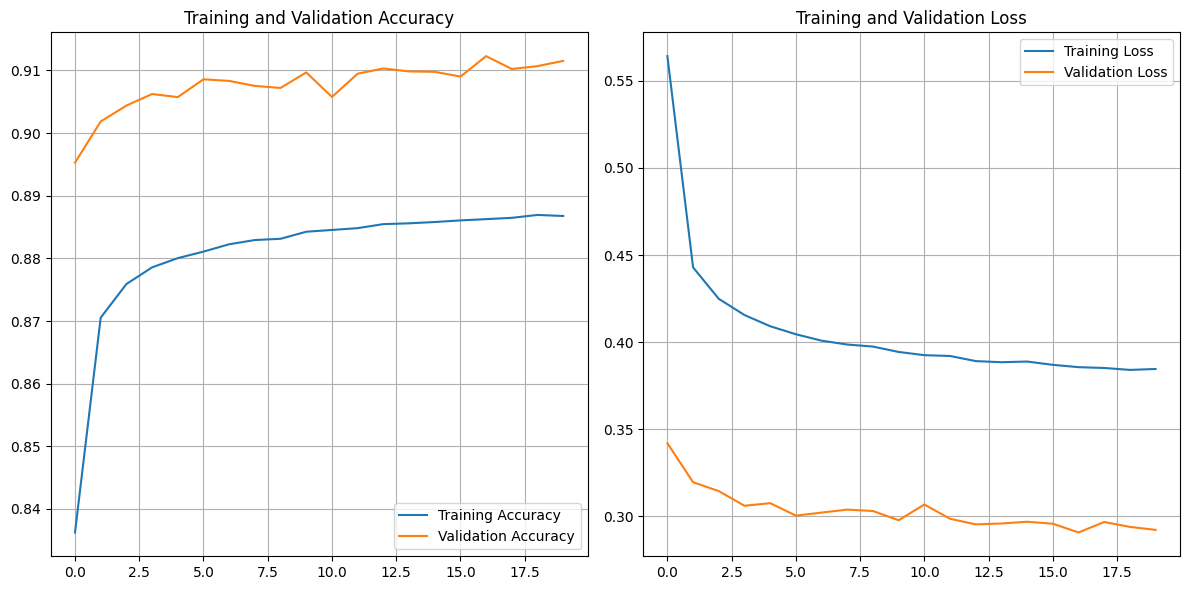


--- Evaluating on Test Set (Phase 1) ---
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - accuracy: 0.9122 - loss: 0.2896
Test Loss: 0.2908
Test Accuracy: 91.23%


In [9]:
# --- Cell 8: Evaluate Initial Training ---

import matplotlib.pyplot as plt

# Plot the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('history_phase1.png')
plt.show()

# Evaluate on the test set
print("\n--- Evaluating on Test Set (Phase 1) ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

In [10]:
# --- Cell 9: Build the Model for Fine-Tuning ---

# To improve accuracy, we "un-freeze" the top layers of the base model
# and re-train with a very low learning rate.

# --- Re-build the model and load the weights we just saved ---
# This ensures we are working from the same architecture
model_ft = build_transfer_model(INPUT_SHAPE, PRETRAINED_INPUT_SHAPE, NUM_CLASSES)
model_ft.load_weights(checkpoint_path) # Load the best weights from Phase 1

# --- Un-freeze the base model ---
base_model = model_ft.layers[4] # This gets the 'model' (MobileNetV2) layer
base_model.trainable = True

# We fine-tune from this layer onwards. A good choice is to un-freeze
# the last block of the model. For MobileNetV2, layer 100 is a good spot.
fine_tune_at = 100 

# Freeze all layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
    
# --- Re-compile with a very low learning rate ---
model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Low learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Re-compiled model for fine-tuning. Layers before {fine_tune_at} are frozen.")
model_ft.summary()

Re-compiled model for fine-tuning. Layers before 100 are frozen.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize (Resizing)   │ (None, 96, 96, 1) │          0 │ input_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ to_rgb              │ (None, 96, 96, 3) │          0 │ resize[0][0],     │
│ (Concatenate)       │                   │            │ resize[0][0],     │
│                     │                   │            │ resize[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescale_to_mobilen… │ (None, 96, 96, 3) │          0 │ to_rgb[0][0]      │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 3, 3,      │  2,257,984 │ rescale_to_mobil… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │    163,968 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_0.5         │ (None, 128)       │          0 │ dense_128[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 20)        │      2,580 │ dropout_0.5[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,424,532 (9.25 MB)

 Trainable params: 2,027,988 (7.74 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [11]:
# --- Cell 10: Train the Model (Phase 2: Fine-Tuning) ---

# Continue training, but now we are also fine-tuning the base model layers
print("--- Starting Training (Phase 2: Fine-Tuning) ---")

FINE_TUNE_EPOCHS = 25
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

# We restore best weights, so we can use a new EarlyStopping callback
early_stopping_ft = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# --- FIX: Use the datagen.flow() generator ---
# We also remove 'steps_per_epoch'
history_fine = model_ft.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=TOTAL_EPOCHS,
    initial_epoch=history.epoch[-1] + 1, # Start from where we left off
    validation_data=(X_test, y_test),
    callbacks=[early_stopping_ft, tensorboard_callback] # No checkpoint needed
)
# --- END FIX ---

print("\n--- Fine-Tuning Complete ---")

--- Starting Training (Phase 2: Fine-Tuning) ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 21/45


E0000 00:00:1762112036.088514      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762112036.233125      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 743/1563 ━━━━━━━━━━━━━━━━━━━━ 1:54 139ms/step - accuracy: 0.6022 - loss: 1.7679

E0000 00:00:1762112150.356250      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762112150.497147      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 306s 178ms/step - accuracy: 0.6854 - loss: 1.3366 - val_accuracy: 0.9017 - val_loss: 0.3779
Epoch 22/45
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 262s 168ms/step - accuracy: 0.8694 - loss: 0.4630 - val_accuracy: 0.9151 - val_loss: 0.3012
Epoch 23/45
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 263s 168ms/step - accuracy: 0.8921 - loss: 0.3810 - val_accuracy: 0.9209 - val_loss: 0.2726
Epoch 24/45
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 262s 168ms/step - accuracy: 0.9035 - loss: 0.3359 - val_accuracy: 0.9265 - val_loss: 0.2515
Epoch 25/45
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 262s 167ms/step - accuracy: 0.9113 - loss: 0.3107 - val_accuracy: 0.9308 - val_loss: 0.2358
Epoch 26/45
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 262s 168ms/step - accuracy: 0.9171 - loss: 0.2898 - val_accuracy: 0.9343 - val_loss: 0.2223
Epoch 27/45
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 262s 167ms/step - accuracy: 0.9212 - loss: 0.2745 - val_accuracy: 0.9368 - val_loss: 0.2149
Epoch 28/45
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 261s 167ms/step - accura


--- Evaluating Final Model ---
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - accuracy: 0.9507 - loss: 0.1649
Final Test Loss: 0.1671
Final Test Accuracy: 95.04%

Generating predictions on test set...
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 88ms/step

--- Classification Report ---

              precision    recall  f1-score   support

       apple       0.99      0.97      0.98     10000
      banana       0.90      0.91      0.90     10000
   butterfly       0.96      0.97      0.97     10000
         car       0.96      0.97      0.97     10000
         cat       0.93      0.85      0.89     10000
       cloud       0.97      0.95      0.96     10000
         cup       0.96      0.97      0.96     10000
         dog       0.82      0.90      0.86     10000
        fish       0.98      0.95      0.97     10000
      flower       0.94      0.95      0.95     10000
        hand       0.97      0.95      0.96     10000
       house       0.99      0.99      0.99     10000
        moon       0.

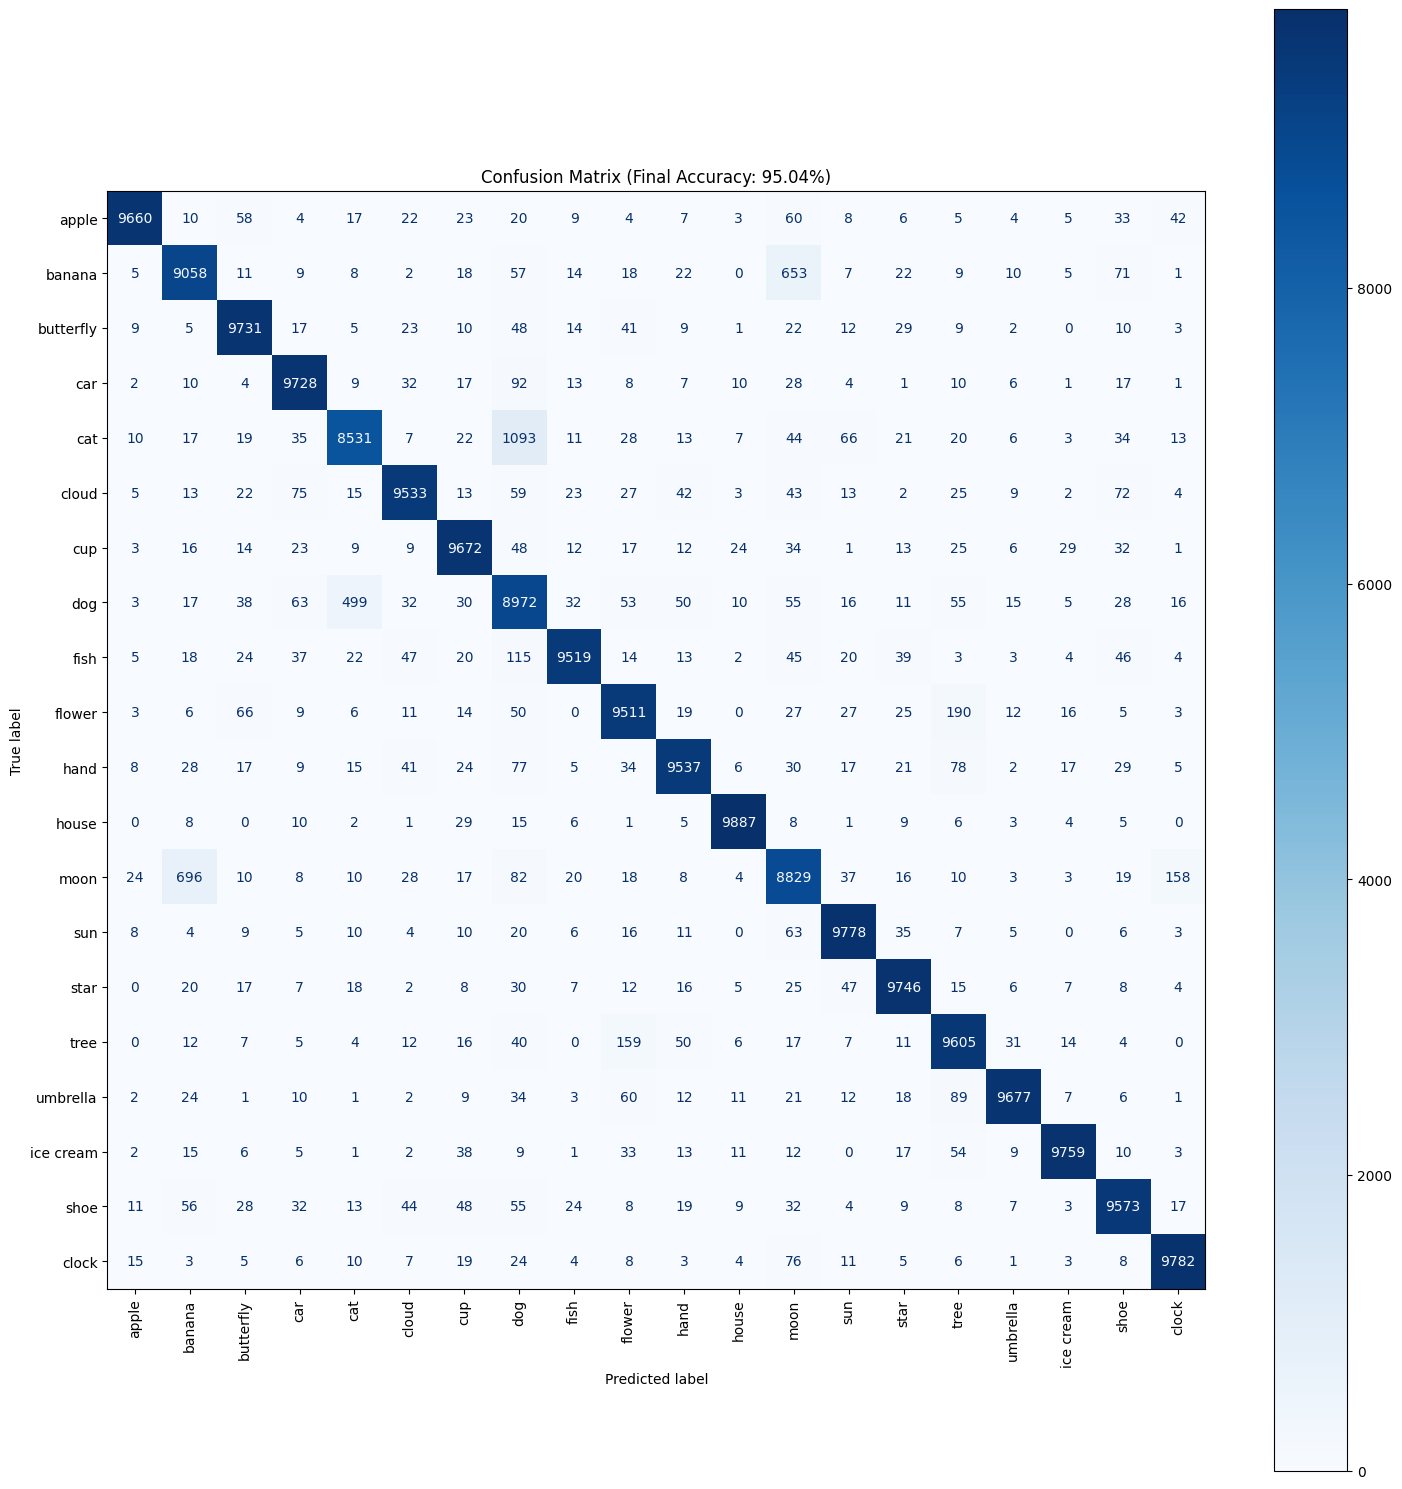

In [12]:
# --- Cell 11: Final Evaluation & Confusion Matrix ---

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np # Make sure numpy is imported if not already

# Evaluate the final, fine-tuned model
print("\n--- Evaluating Final Model ---")
final_loss, final_acc = model_ft.evaluate(X_test, y_test, verbose=1)
print(f"Final Test Loss: {final_loss:.4f}")
print(f"Final Test Accuracy: {final_acc * 100:.2f}%")

# Generate predictions to build the report and matrix
print("\nGenerating predictions on test set...")
y_pred_probs = model_ft.predict(X_test, batch_size=BATCH_SIZE)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# --- FIX: Use the 1D 'y_true' variable created in Cell 4 ---
# (which was named y_test_labels in that cell)
y_true = y_test_labels 
# --- END FIX ---

# --- Classification Report ---
print("\n--- Classification Report ---\n")
print(classification_report(y_true, y_pred, target_names=classes))

# --- Confusion Matrix ---
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d')
plt.title(f'Confusion Matrix (Final Accuracy: {final_acc*100:.2f}%)')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

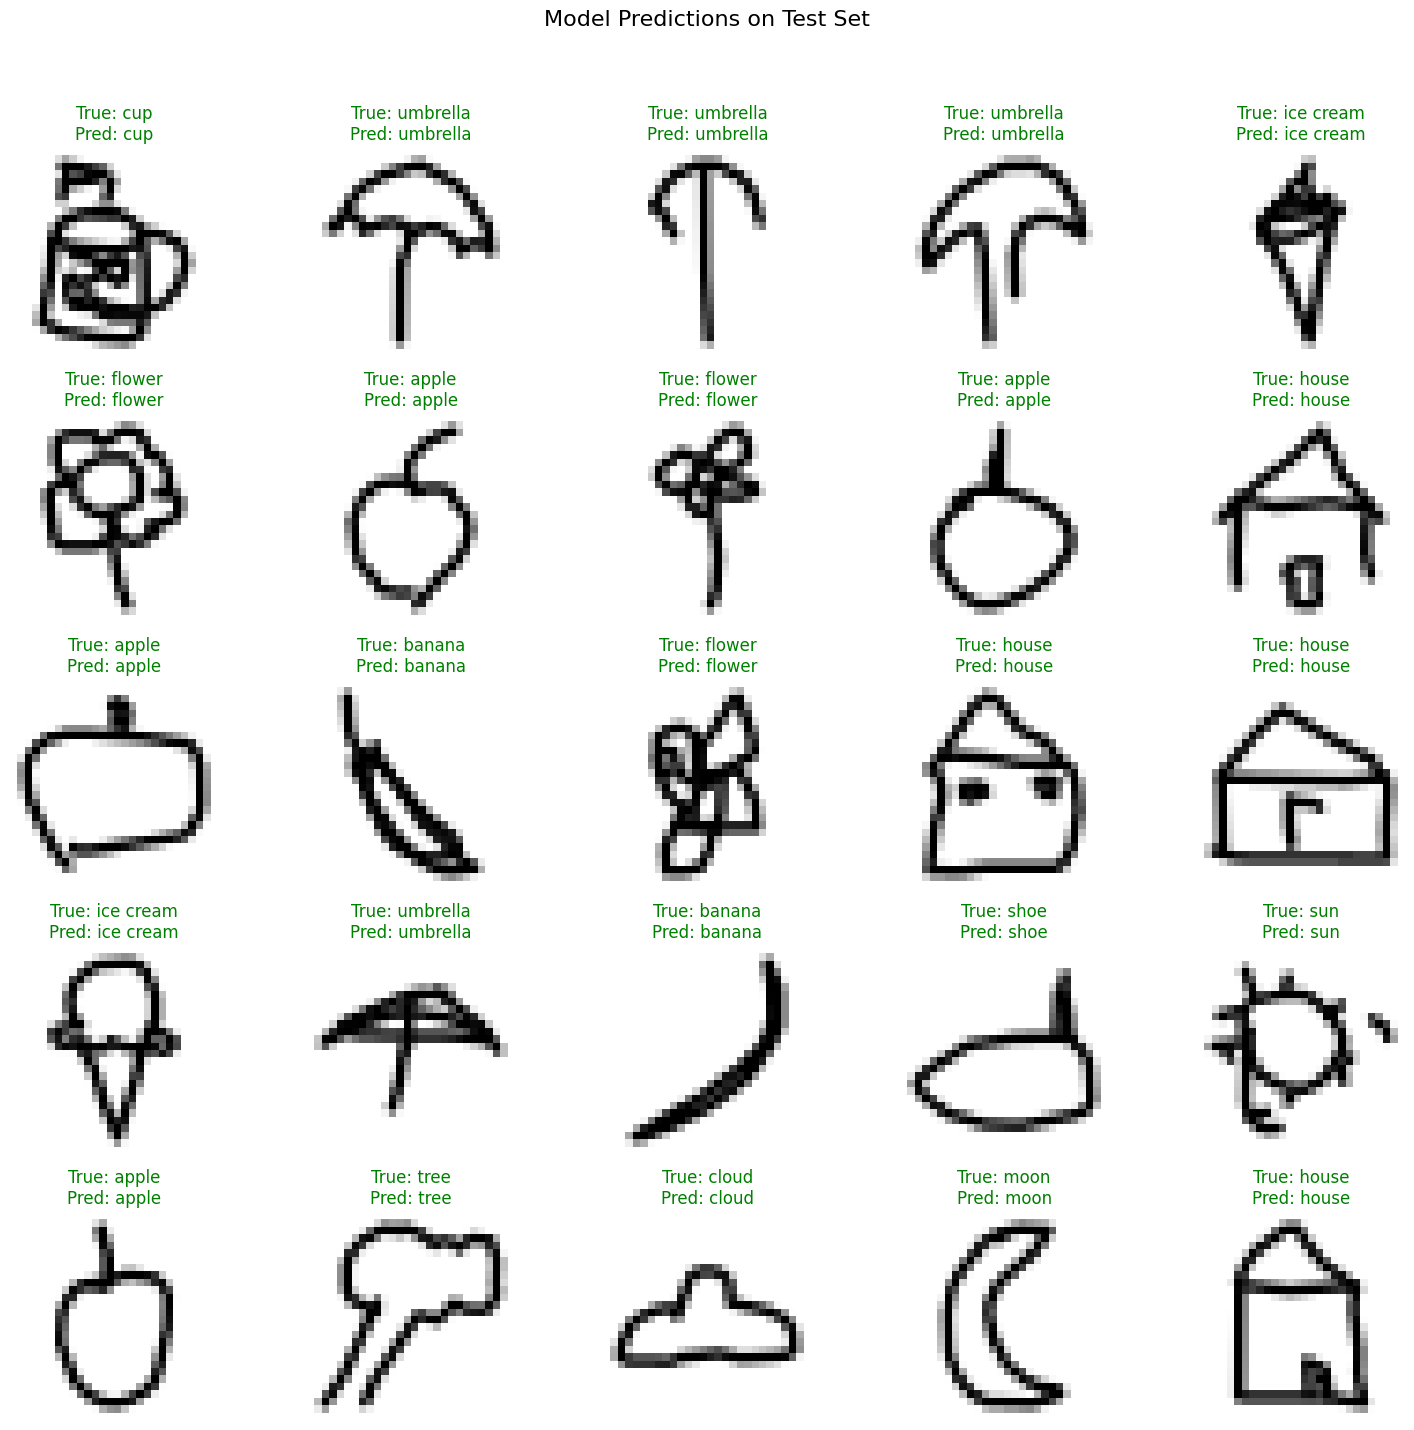

In [13]:
# --- Cell 12: Visualize Final Predictions ---

# This cell shows a random sample of test images, their true labels,
# and the model's predictions.
import random
import numpy as np # Make sure numpy is imported

plt.figure(figsize=(15, 15))
num_images_to_show = 25

# Get random indices from the test set
random_indices = random.sample(range(len(X_test)), num_images_to_show)

for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i + 1)
    # Reshape the (28, 28, 1) image for plotting
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    
    # --- FIX: Use the 1D y_true (y_test_labels) variable ---
    true_label = classes[y_true[idx]]
    # --- END FIX ---
    pred_label = classes[y_pred[idx]] # y_pred is from Cell 11
    
    # Set title color to green for correct, red for incorrect
    title_color = 'green' if true_label == pred_label else 'red'
    
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=title_color)
    plt.axis('off')

plt.suptitle("Model Predictions on Test Set", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('final_predictions.png')
plt.show()

In [14]:
# --- Cell 13: Save the Final Model and Label Map ---

import json

# --- Save the complete .h5 model ---
# This single file contains the architecture, weights, and optimizer state.
final_model_path = '/kaggle/working/doodle_model.h5'
model_ft.save(final_model_path)
print(f"Final model saved to: {final_model_path}")

# --- Save the label map for the web app ---
# Your web app needs this to know that class '0' is 'apple', etc.
label_map_file = '/kaggle/working/label_map.json'

# The old map was {0: 'apple', ...}. 
# The new app.py (from your original files) seems to expect {"labels": ["apple", ...]}
# Let's create the format your app.py expects.
app_label_map = {"labels": classes}

with open(label_map_file, 'w') as f:
    json.dump(app_label_map, f)

print(f"Label map saved to: {label_map_file}")
print("\n--- Notebook Complete ---")
# --- FIX: Print .h5 to match the filename ---
print("You can now download 'doodle_model.h5' and 'label_map.json' from the /kaggle/working/ directory.")

Final model saved to: /kaggle/working/doodle_model.h5
Label map saved to: /kaggle/working/label_map.json

--- Notebook Complete ---
You can now download 'doodle_model.h5' and 'label_map.json' from the /kaggle/working/ directory.
